# Directional proximity analysis of cultivation-plot DGR

## Setup

In [ ]:
options(scipen = 999)

required_packages <- c(
  "sf",
  "dplyr",
  "tidyr",
  "purrr",
  "ggplot2",
  "patchwork",
  "broom",
  "readxl",
  "stringr"
)

missing_packages <- required_packages[!vapply(
  required_packages,
  requireNamespace,
  quietly = TRUE,
  FUN.VALUE = logical(1)
)]

if (length(missing_packages) > 0) {
  stop(
    paste(
      "Missing required package(s):",
      paste(missing_packages, collapse = ", "),
      "\nInstall them before rendering this Quarto document."
    ),
    call. = FALSE
  )
}

library(sf)


Linking to GEOS 3.14.1, GDAL 3.12.1, PROJ 9.7.1; sf_use_s2() is TRUE


Attachement du package : 'dplyr'

Les objets suivants sont masqués depuis 'package:stats':

    filter, lag

Les objets suivants sont masqués depuis 'package:base':

    intersect, setdiff, setequal, union

## User Parameters

In [ ]:
cadaster_path <- "Data/shp/Cadaster_NBS_Dec2025.shp"
dgr_col <- "DGR"
id_col <- "ID"

output_dir <- "Figures/Spatial_analysis"
distance_thresholds <- seq(10, 500, by = 10)
direction_levels <- c("All", "SW", "NW", "NE", "SE")
sector_levels <- c("SW", "NW", "NE", "SE")

primary_predictors <- c("proximity_pressure", "n_neighbours")
all_predictors <- c(
  "has_neighbour",
  "n_neighbours",
  "neighbour_density_per_ha",
  "proximity_pressure",
  "nearest_distance_m"
)

min_model_n <- 10
save_dpi <- 300
plot_width <- 8.5
plot_height <- 6.0

derive_dgr_if_missing <- TRUE
harvest_path <- "Data/NBS - Récolte 2025.xlsx"
harvest_sheet <- "Copie base donnée"
harvest_join_col <- "Module_ID"
derived_dgr_col <- "Average_DGR"


## Helper Functions

In [ ]:
save_plot <- function(plot_obj, filename, width = plot_width, height = plot_height) {
  ggplot2::ggsave(
    filename = filename,
    plot = plot_obj,
    width = width,
    height = height,
    units = "in",
    dpi = save_dpi,
    bg = "white"
  )
}

theme_spatial <- function() {
  theme_minimal(base_size = 11) +
    theme(
      panel.grid.major = element_line(colour = "grey88", linewidth = 0.25),
      panel.grid.minor = element_blank(),
      strip.text = element_text(face = "bold"),
      axis.title = element_text(face = "bold"),
      legend.title = element_text(face = "bold"),
      plot.title = element_text(face = "bold", size = 13),
      plot.subtitle = element_text(size = 10),
      plot.caption = element_text(size = 8, colour = "grey35")
    )
}

direction_palette <- c(
  All = "#222222",
  SW = "#E64B35",
  NW = "#4DBBD5",
  NE = "#00A087",
  SE = "#3C5488"
)

predictor_labels <- c(
  has_neighbour = "Neighbour present",
  n_neighbours = "Number of neighbours",
  neighbour_density_per_ha = "Neighbour density (plots/ha)",
  proximity_pressure = "Proximity pressure (sum 1/d)",
  nearest_distance_m = "Nearest-neighbour distance (m)"
)

guess_utm_epsg <- function(sf_obj) {
  centroid_wgs84 <- st_as_sfc(st_bbox(sf_obj)) |>
    st_transform(4326) |>
    st_centroid()

  centroid_xy <- st_coordinates(centroid_wgs84)
  lon <- centroid_xy[1, "X"]
  lat <- centroid_xy[1, "Y"]
  zone <- floor((lon + 180) / 6) + 1
  if (lat >= 0) 32600 + zone else 32700 + zone
}

derive_dgr_from_harvest <- function(
  harvest_path,
  harvest_sheet,
  derived_dgr_col = "Average_DGR"
) {
  if (!file.exists(harvest_path)) {
    stop(
      paste(
        "DGR column was not found in the shapefile and the fallback harvest file",
        "does not exist:",
        harvest_path
      ),
      call. = FALSE
    )
  }

  harvest_tbl <- readxl::read_excel(harvest_path, sheet = harvest_sheet) |>
    mutate(
      FarmID = as.numeric(FarmID),
      ModuleNumber = as.numeric(ModuleNumber),
      Harvested_Weight = as.numeric(Harvested_Weight),
      CultureDuration_days = as.numeric(CultureDuration_days),
      LinesCount = as.numeric(LinesCount)
    ) |>
    filter(
      CultureMode == "Cordes",
      !is.na(FarmID),
      !is.na(ModuleNumber),
      !is.na(Harvested_Weight),
      !is.na(CultureDuration_days),
      CultureDuration_days > 0,
      !is.na(LinesCount),
      LinesCount == 100,
      Harvested_Weight > 1000
    ) |>
    mutate(
      FarmID = stringr::str_pad(as.integer(FarmID), width = 3, pad = "0"),
      ModuleNumber = as.integer(ModuleNumber),
      Module_ID = paste0(FarmID, "_", ModuleNumber),
      DGR = (log(Harvested_Weight / 700) / CultureDuration_days) * 100
    ) |>
    group_by(Module_ID) |>
    summarise(
      Average_DGR = mean(DGR, na.rm = TRUE),
      .groups = "drop"
    )

  names(harvest_tbl)[names(harvest_tbl) == "Average_DGR"] <- derived_dgr_col
  harvest_tbl
}

prepare_cadaster <- function(
  cadaster_path,
  dgr_col,
  id_col,
  derive_dgr_if_missing = FALSE,
  harvest_path = NULL,
  harvest_sheet = NULL,
  harvest_join_col = "Module_ID",
  derived_dgr_col = "Average_DGR"
) {
  if (!file.exists(cadaster_path)) {
    stop(paste("Cadaster shapefile not found:", cadaster_path), call. = FALSE)
  }

  cadaster_sf <- st_read(cadaster_path, quiet = TRUE)
  cadaster_sf <- st_make_valid(cadaster_sf)

  if (!id_col %in% names(cadaster_sf)) {
    stop(
      paste("The plot identifier column was not found in the shapefile:", id_col),
      call. = FALSE
    )
  }

  original_crs <- st_crs(cadaster_sf)
  if (is.na(original_crs)) {
    stop("The input shapefile has no CRS defined.", call. = FALSE)
  }

  original_crs_label <- original_crs$input
  transformed_crs_label <- original_crs_label

  if (isTRUE(st_is_longlat(cadaster_sf))) {
    utm_epsg <- guess_utm_epsg(cadaster_sf)
    cadaster_sf <- st_transform(cadaster_sf, utm_epsg)
    transformed_crs_label <- paste0("EPSG:", utm_epsg)
  } else {
    crs_units_raw <- original_crs$units_gdal
    crs_units <- if (is.null(crs_units_raw) || length(crs_units_raw) == 0 || is.na(crs_units_raw)) {
      ""
    } else {
      tolower(crs_units_raw)
    }
    if (!crs_units %in% c("metre", "meter", "m")) {
      utm_epsg <- guess_utm_epsg(cadaster_sf)
      cadaster_sf <- st_transform(cadaster_sf, utm_epsg)
      transformed_crs_label <- paste0("EPSG:", utm_epsg)
    }
  }

  working_dgr_col <- dgr_col
  dgr_source <- "shapefile"

  if (!dgr_col %in% names(cadaster_sf)) {
    if (!derive_dgr_if_missing) {
      stop(
        paste("The requested DGR column was not found in the shapefile:", dgr_col),
        call. = FALSE
      )
    }

    derived_dgr_tbl <- derive_dgr_from_harvest(
      harvest_path = harvest_path,
      harvest_sheet = harvest_sheet,
      derived_dgr_col = derived_dgr_col
    )

    cadaster_sf <- cadaster_sf |>
      left_join(
        derived_dgr_tbl,
        by = setNames(harvest_join_col, id_col)
      )

    working_dgr_col <- derived_dgr_col
    dgr_source <- "derived_from_harvest_workbook"
  }

  cadaster_sf <- cadaster_sf |>
    mutate(
      plot_id = as.character(.data[[id_col]]),
      DGR = suppressWarnings(as.numeric(.data[[working_dgr_col]]))
    )

  if (anyDuplicated(cadaster_sf$plot_id) > 0) {
    stop("The selected plot identifier column is not unique.", call. = FALSE)
  }

  dropped_missing_dgr <- sum(is.na(cadaster_sf$DGR))
  cadaster_sf <- cadaster_sf |>
    filter(!is.na(DGR))

  if (nrow(cadaster_sf) < 5) {
    stop("Too few plots remain after removing missing DGR values.", call. = FALSE)
  }

  centroid_points <- st_point_on_surface(cadaster_sf)
  centroid_coords <- st_coordinates(centroid_points)

  cadaster_sf <- cadaster_sf |>
    mutate(
      x = centroid_coords[, "X"],
      y = centroid_coords[, "Y"]
    )

  list(
    data = cadaster_sf,
    metadata = list(
      original_crs = original_crs_label,
      analysis_crs = transformed_crs_label,
      dgr_source = dgr_source,
      working_dgr_col = working_dgr_col,
      dropped_missing_dgr = dropped_missing_dgr
    )
  )
}

classify_direction <- function(dx, dy) {
  dplyr::case_when(
    dx > 0 & dy > 0 ~ "NE",
    dx < 0 & dy > 0 ~ "NW",
    dx < 0 & dy < 0 ~ "SW",
    dx > 0 & dy < 0 ~ "SE",
    TRUE ~ NA_character_
  )
}

build_pairwise_table <- function(plot_sf, sector_levels) {
  plot_tbl <- plot_sf |>
    st_drop_geometry() |>
    select(plot_id, DGR, x, y)

  pairwise_all <- tidyr::expand_grid(
    focal_index = seq_len(nrow(plot_tbl)),
    neighbour_index = seq_len(nrow(plot_tbl))
  ) |>
    filter(focal_index != neighbour_index) |>
    transmute(
      focal_index = focal_index,
      neighbour_index = neighbour_index,
      plot_id = plot_tbl$plot_id[focal_index],
      neighbour_id = plot_tbl$plot_id[neighbour_index],
      focal_DGR = plot_tbl$DGR[focal_index],
      dx = plot_tbl$x[neighbour_index] - plot_tbl$x[focal_index],
      dy = plot_tbl$y[neighbour_index] - plot_tbl$y[focal_index]
    ) |>
    mutate(
      distance_m = sqrt(dx^2 + dy^2),
      bearing_deg = (atan2(dy, dx) * 180 / pi + 360) %% 360,
      direction = classify_direction(dx, dy)
    )

  pairwise_directional <- pairwise_all |>
    filter(!is.na(direction)) |>
    mutate(direction = factor(direction, levels = sector_levels))

  list(
    pairwise_all = pairwise_all,
    pairwise_directional = pairwise_directional
  )
}

compute_proximity_metrics <- function(
  pairwise_all,
  pairwise_directional,
  plot_sf,
  distance_thresholds,
  direction_levels,
  sector_levels
) {
  focal_tbl <- plot_sf |>
    st_drop_geometry() |>
    select(plot_id, DGR)

  overall_grid <- tidyr::expand_grid(
    plot_id = focal_tbl$plot_id,
    direction = factor("All", levels = direction_levels)
  )

  sector_grid <- tidyr::expand_grid(
    plot_id = focal_tbl$plot_id,
    direction = factor(sector_levels, levels = direction_levels)
  )

  purrr::map_dfr(distance_thresholds, function(threshold_m) {
    overall_area_ha <- (pi * threshold_m^2) / 10000
    sector_area_ha <- ((pi * threshold_m^2) / 4) / 10000

    overall_summary <- pairwise_all |>
      filter(distance_m > 0, distance_m <= threshold_m) |>
      group_by(plot_id) |>
      summarise(
        has_neighbour = 1L,
        n_neighbours = dplyr::n(),
        nearest_distance_m = min(distance_m, na.rm = TRUE),
        mean_distance_m = mean(distance_m, na.rm = TRUE),
        proximity_pressure = sum(1 / distance_m, na.rm = TRUE),
        .groups = "drop"
      ) |>
      mutate(
        direction = factor("All", levels = direction_levels),
        neighbour_density_per_ha = n_neighbours / overall_area_ha
      )

    sector_summary <- pairwise_directional |>
      filter(distance_m > 0, distance_m <= threshold_m) |>
      group_by(plot_id, direction) |>
      summarise(
        has_neighbour = 1L,
        n_neighbours = dplyr::n(),
        nearest_distance_m = min(distance_m, na.rm = TRUE),
        mean_distance_m = mean(distance_m, na.rm = TRUE),
        proximity_pressure = sum(1 / distance_m, na.rm = TRUE),
        .groups = "drop"
      ) |>
      mutate(
        neighbour_density_per_ha = n_neighbours / sector_area_ha
      )

    bind_rows(
      overall_grid |>
        left_join(overall_summary, by = c("plot_id", "direction")),
      sector_grid |>
        left_join(sector_summary, by = c("plot_id", "direction"))
    ) |>
      mutate(
        distance_threshold_m = threshold_m,
        has_neighbour = tidyr::replace_na(has_neighbour, 0L),
        n_neighbours = tidyr::replace_na(n_neighbours, 0L),
        neighbour_density_per_ha = tidyr::replace_na(neighbour_density_per_ha, 0),
        proximity_pressure = tidyr::replace_na(proximity_pressure, 0)
      ) |>
      left_join(focal_tbl, by = "plot_id")
  })
}

safe_lm_summary <- function(data, predictor, response = "DGR", min_n = 10) {
  model_data <- data |>
    select(all_of(c(response, predictor))) |>
    tidyr::drop_na()

  if (nrow(model_data) < min_n) {
    return(tibble(
      predictor = predictor,
      slope = NA_real_,
      p_value = NA_real_,
      r_squared = NA_real_,
      adj_r_squared = NA_real_,
      AIC = NA_real_,
      sample_size = nrow(model_data),
      conf_low = NA_real_,
      conf_high = NA_real_,
      status = paste0("Skipped: sample size < ", min_n)
    ))
  }

  if (dplyr::n_distinct(model_data[[predictor]]) < 2) {
    return(tibble(
      predictor = predictor,
      slope = NA_real_,
      p_value = NA_real_,
      r_squared = NA_real_,
      adj_r_squared = NA_real_,
      AIC = NA_real_,
      sample_size = nrow(model_data),
      conf_low = NA_real_,
      conf_high = NA_real_,
      status = "Skipped: predictor has insufficient variation"
    ))
  }

  fit <- tryCatch(
    stats::lm(stats::as.formula(paste(response, "~", predictor)), data = model_data),
    error = function(e) e
  )

  if (inherits(fit, "error")) {
    return(tibble(
      predictor = predictor,
      slope = NA_real_,
      p_value = NA_real_,
      r_squared = NA_real_,
      adj_r_squared = NA_real_,
      AIC = NA_real_,
      sample_size = nrow(model_data),
      conf_low = NA_real_,
      conf_high = NA_real_,
      status = paste("Skipped:", fit$message)
    ))
  }

  fit_tidy <- broom::tidy(fit, conf.int = TRUE)
  fit_glance <- broom::glance(fit)
  slope_row <- fit_tidy |>
    filter(term == predictor)

  tibble(
    predictor = predictor,
    slope = slope_row$estimate[1],
    p_value = slope_row$p.value[1],
    r_squared = fit_glance$r.squared[1],
    adj_r_squared = fit_glance$adj.r.squared[1],
    AIC = stats::AIC(fit),
    sample_size = stats::nobs(fit),
    conf_low = slope_row$conf.low[1],
    conf_high = slope_row$conf.high[1],
    status = "OK"
  )
}

fit_proximity_models <- function(metrics_tbl, predictors, min_model_n = 10) {
  split_tbl <- split(
    metrics_tbl,
    list(metrics_tbl$direction, metrics_tbl$distance_threshold_m),
    drop = TRUE
  )

  purrr::map_dfr(split_tbl, function(group_df) {
    group_direction <- as.character(unique(group_df$direction))
    group_threshold <- unique(group_df$distance_threshold_m)

    purrr::map_dfr(
      predictors,
      ~ safe_lm_summary(group_df, predictor = .x, min_n = min_model_n)
    ) |>
      mutate(
        direction = group_direction,
        distance_threshold_m = group_threshold
      ) |>
      relocate(direction, distance_threshold_m, predictor)
  })
}

effect_text_from_row <- function(predictor, slope) {
  if (is.na(slope)) {
    return(NA_character_)
  }

  if (predictor %in% c("has_neighbour", "n_neighbours", "neighbour_density_per_ha", "proximity_pressure")) {
    if (slope > 0) {
      return("more nearby plots are associated with higher DGR")
    }
    if (slope < 0) {
      return("more nearby plots are associated with lower DGR")
    }
    return("no directional effect detected")
  }

  if (predictor == "nearest_distance_m") {
    if (slope > 0) {
      return("more spacing to the nearest plot is associated with higher DGR")
    }
    if (slope < 0) {
      return("closer nearest plots are associated with higher DGR")
    }
    return("no nearest-neighbour distance effect detected")
  }

  NA_character_
}

make_metric_plot <- function(model_results, predictor, y_var, y_label, title_text, filename) {
  plot_obj <- model_results |>
    filter(.data$predictor == predictor) |>
    ggplot(aes(x = distance_threshold_m, y = .data[[y_var]], colour = direction)) +
    geom_line(linewidth = 0.8, na.rm = TRUE) +
    geom_point(size = 1.7, na.rm = TRUE) +
    scale_colour_manual(values = direction_palette, drop = FALSE) +
    labs(
      title = title_text,
      subtitle = predictor_labels[[predictor]],
      x = "Distance threshold (m)",
      y = y_label,
      colour = "Direction"
    ) +
    theme_spatial()

  save_plot(plot_obj, filename)
  plot_obj
}

write_interpretation <- function(
  output_file,
  metadata,
  strongest_overall_row,
  strongest_directional_rows,
  best_summary
) {
  overall_text <- if (nrow(strongest_overall_row) == 1) {
    sprintf(
      paste(
        "Across all directions combined, the strongest tested crowding signal was",
        "%s at %d m using %s (R2 = %.3f, slope = %.3f, p = %.3f), meaning %s."
      ),
      strongest_overall_row$direction[1],
      strongest_overall_row$best_r2_threshold_m[1],
      predictor_labels[[strongest_overall_row$best_predictor[1]]],
      strongest_overall_row$best_r2[1],
      strongest_overall_row$best_slope[1],
      strongest_overall_row$best_p_value[1],
      strongest_overall_row$effect_interpretation[1]
    )
  } else {
    "No overall crowding model satisfied the minimum modelling criteria."
  }

  directional_lines <- strongest_directional_rows |>
    filter(direction != "All", !is.na(best_r2)) |>
    arrange(desc(best_r2), direction) |>
    mutate(
      text = sprintf(
        "- %s: best signal at %d m using %s (R2 = %.3f, slope = %.3f, p = %.3f), meaning %s.",
        direction,
        best_r2_threshold_m,
        predictor_labels[best_predictor],
        best_r2,
        best_slope,
        best_p_value,
        effect_interpretation
      )
    ) |>
    pull(text)

  shortest_threshold_lines <- best_summary |>
    filter(!is.na(shortest_significant_threshold_m)) |>
    arrange(direction, predictor) |>
    mutate(
      text = sprintf(
        "- %s / %s: shortest threshold with p < 0.05 was %d m.",
        direction,
        predictor_labels[predictor],
        shortest_significant_threshold_m
      )
    ) |>
    pull(text)

  interpretation_lines <- c(
    "# Proximity analysis interpretation",
    "",
    "## Data context",
    sprintf("- Input shapefile: `%s`", cadaster_path),
    sprintf("- DGR source used in the analysis: `%s`", metadata$dgr_source),
    sprintf("- Original CRS: `%s`", metadata$original_crs),
    sprintf("- Analysis CRS: `%s`", metadata$analysis_crs),
    sprintf("- Plots removed because of missing DGR: `%d`", metadata$dropped_missing_dgr),
    "",
    "## Main interpretation",
    paste0("- ", overall_text),
    "- Directional models were compared using neighbour presence, neighbour count, neighbour density, crowding pressure, and nearest-neighbour distance.",
    "- The best model in each direction is listed below."
  )

  if (length(directional_lines) > 0) {
    interpretation_lines <- c(interpretation_lines, directional_lines)
  }

  interpretation_lines <- c(
    interpretation_lines,
    "",
    "## Shortest tested thresholds showing evidence of an effect"
  )

  if (length(shortest_threshold_lines) > 0) {
    interpretation_lines <- c(interpretation_lines, shortest_threshold_lines)
  } else {
    interpretation_lines <- c(
      interpretation_lines,
      "- No model reached p < 0.05 under the tested thresholds."
    )
  }

  interpretation_lines <- c(
    interpretation_lines,
    "",
    "## Cautions",
    "- This is an exploratory analysis of association, not proof that neighbouring plots cause a change in DGR.",
    "- Repeated threshold testing means the results should be judged mainly by consistency, effect size, and R2 rather than by p-values alone.",
    "- If plot placement follows environmental gradients, proximity effects may partly reflect shared environment rather than crowding itself.",
    "",
    "## Recommended next step",
    "- Add environmental covariates such as depth, exposure, current regime, or farm identity to separate crowding effects from habitat effects."
  )

  writeLines(interpretation_lines, con = output_file)
}


## Load And Prepare The Cadaster

In [ ]:
dir.create(output_dir, showWarnings = FALSE, recursive = TRUE)

prep <- prepare_cadaster(
  cadaster_path = cadaster_path,
  dgr_col = dgr_col,
  id_col = id_col,
  derive_dgr_if_missing = derive_dgr_if_missing,
  harvest_path = harvest_path,
  harvest_sheet = harvest_sheet,
  harvest_join_col = harvest_join_col,
  derived_dgr_col = derived_dgr_col
)


Original CRS: WGS 84 / UTM zone 39S 

Analysis CRS: WGS 84 / UTM zone 39S 

DGR source: derived_from_harvest_workbook 

Plots used: 683 

Plots removed because of missing DGR: 30 

## Map Of DGR

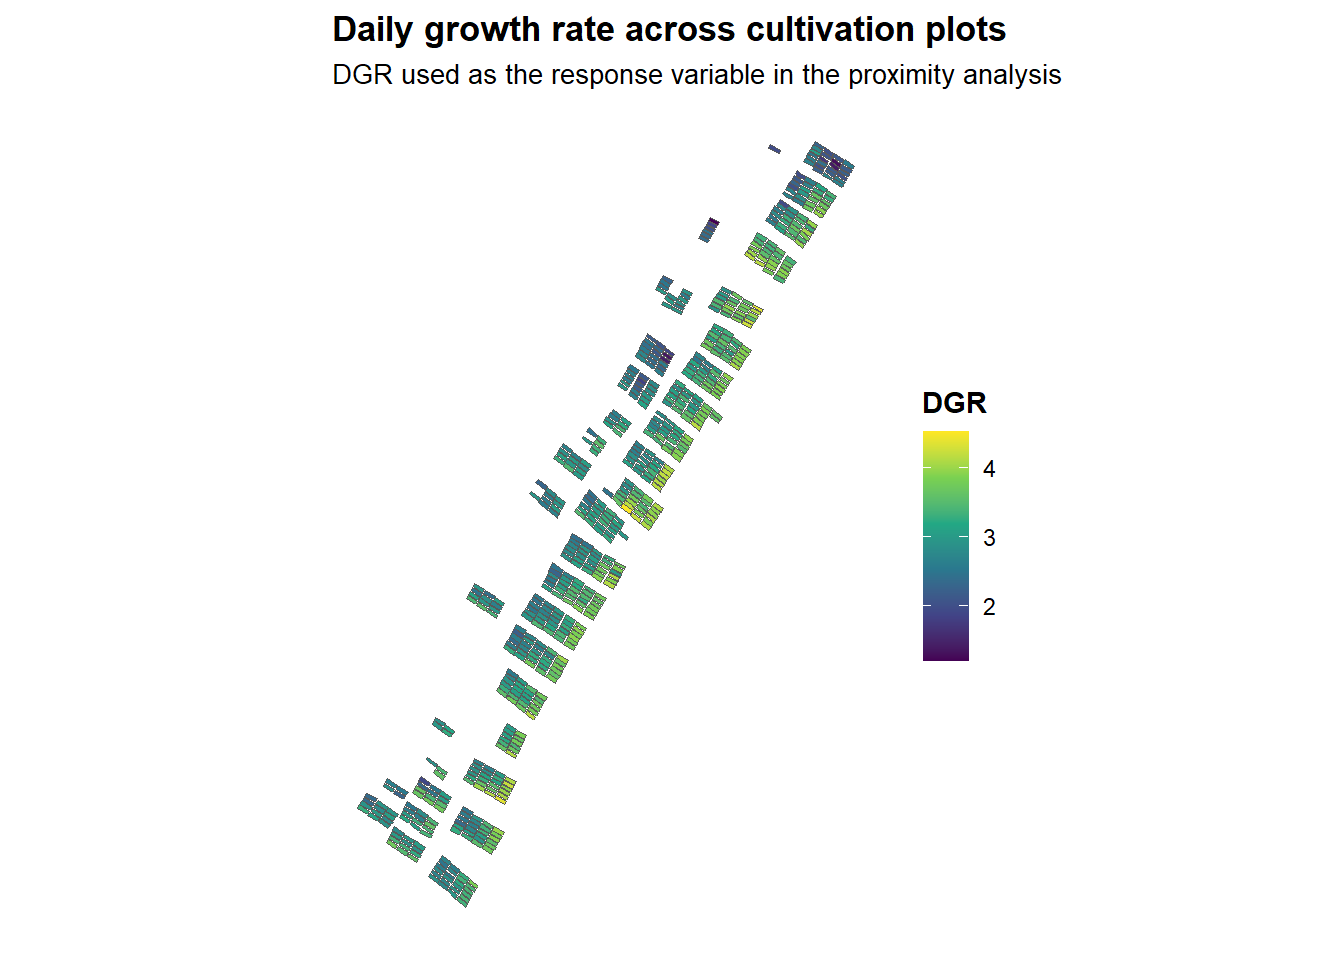

In [ ]:
dgr_map <- ggplot(plot_sf) +
  geom_sf(aes(fill = DGR), colour = "grey35", linewidth = 0.08) +
  scale_fill_viridis_c(option = "D", name = "DGR") +
  labs(
    title = "Daily growth rate across cultivation plots",
    subtitle = "DGR used as the response variable in the proximity analysis",
    x = NULL,
    y = NULL
  ) +
  coord_sf(datum = NA) +
  theme_spatial()

save_plot(
  dgr_map,
  file.path(output_dir, "proximity_dgr_map.png"),
  width = 8.5,
  height = 6.5
)

dgr_map


## Build Pairwise Distances And Directions

In [ ]:
pairwise_objects <- build_pairwise_table(plot_sf, sector_levels = sector_levels)
pairwise_all <- pairwise_objects$pairwise_all
pairwise_directional <- pairwise_objects$pairwise_directional

cat("Directed plot pairs retained:", nrow(pairwise_directional), "\n")


Directed plot pairs retained: 465806 

All plot pairs retained: 465806 

## Proximity Metrics

In [ ]:
proximity_metrics_tbl <- compute_proximity_metrics(
  pairwise_all = pairwise_all,
  pairwise_directional = pairwise_directional,
  plot_sf = plot_sf,
  distance_thresholds = distance_thresholds,
  direction_levels = direction_levels,
  sector_levels = sector_levels
)


ℹ In argument: `nearest_distance_m = min(distance_m, na.rm = TRUE)`.
Caused by warning in `min()`:
! aucun argument trouvé pour min ; Inf est renvoyé
There was 1 warning in `summarise()`.
ℹ In argument: `nearest_distance_m = min(distance_m, na.rm = TRUE)`.
Caused by warning in `min()`:
! aucun argument trouvé pour min ; Inf est renvoyé

# A tibble: 6 × 10
  ID    direction has_neighbour n_neighbours nearest_distance_m mean_distance_m
  <chr> <fct>             <int>        <int>              <dbl>           <dbl>
1 001_1 All                   0            0               NA              NA  
2 001_1 All                   1            2               16.7            16.9
3 001_1 All                   1            2               16.7            16.9
4 001_1 All                   1            3               16.7            22.8
5 001_1 All                   1            5               16.7            32.8
6 001_1 All                   1            6               16.7            36.1
# ℹ 4 more variables: proximity_pressure <dbl>, neighbour_density_per_ha <dbl>,
#   distance_threshold_m <dbl>, DGR <dbl>

## Proximity Models

In [ ]:
proximity_model_results <- fit_proximity_models(
  metrics_tbl = proximity_metrics_tbl,
  predictors = all_predictors,
  min_model_n = min_model_n
) |>
  mutate(
    effect_interpretation = mapply(effect_text_from_row, predictor, slope)
  ) |>
  arrange(direction, predictor, distance_threshold_m)

utils::write.csv(
  proximity_model_results,
  file.path(output_dir, "proximity_model_results.csv"),
  row.names = FALSE
)

head(proximity_model_results)


# A tibble: 6 × 13
  direction distance_threshold_m predictor      slope  p_value r_squared
  <chr>                    <dbl> <chr>          <dbl>    <dbl>     <dbl>
1 All                         10 has_neighbour NA     NA        NA      
2 All                         20 has_neighbour  0.366  0.0190    0.00806
3 All                         30 has_neighbour  0.550  0.00389   0.0122 
4 All                         40 has_neighbour  0.583  0.00799   0.0103 
5 All                         50 has_neighbour  1.19   0.0263    0.00722
6 All                         60 has_neighbour  1.19   0.0263    0.00722
# ℹ 7 more variables: adj_r_squared <dbl>, AIC <dbl>, sample_size <int>,
#   conf_low <dbl>, conf_high <dbl>, status <chr>, effect_interpretation <chr>

## Best Model Summary

In [ ]:
best_summary <- proximity_model_results |>
  filter(!is.na(r_squared)) |>
  group_by(direction, predictor) |>
  arrange(desc(r_squared), p_value, distance_threshold_m, .by_group = TRUE) |>
  slice(1) |>
  ungroup() |>
  transmute(
    direction,
    predictor,
    best_r2_threshold_m = distance_threshold_m,
    best_r2 = r_squared,
    best_slope = slope,
    best_p_value = p_value,
    best_AIC = AIC,
    sample_size = sample_size,
    effect_interpretation = effect_interpretation
  ) |>
  left_join(
    proximity_model_results |>
      filter(!is.na(AIC)) |>
      group_by(direction, predictor) |>
      arrange(AIC, distance_threshold_m, .by_group = TRUE) |>
      slice(1) |>
      ungroup() |>
      transmute(
        direction,
        predictor,
        best_aic_threshold_m = distance_threshold_m,
        best_aic = AIC
      ),
    by = c("direction", "predictor")
  ) |>
  left_join(
    proximity_model_results |>
      filter(!is.na(p_value), p_value < 0.05) |>
      group_by(direction, predictor) |>
      arrange(distance_threshold_m, .by_group = TRUE) |>
      slice(1) |>
      ungroup() |>
      transmute(
        direction,
        predictor,
        shortest_significant_threshold_m = distance_threshold_m
      ),
    by = c("direction", "predictor")
  ) |>
  arrange(direction, predictor)

utils::write.csv(
  best_summary,
  file.path(output_dir, "best_proximity_model_summary.csv"),
  row.names = FALSE
)

best_summary


# A tibble: 25 × 12
   direction predictor       best_r2_threshold_m best_r2 best_slope best_p_value
   <chr>     <chr>                         <dbl>   <dbl>      <dbl>        <dbl>
 1 All       has_neighbour                    30  0.0122    0.550        3.89e-3
 2 All       n_neighbours                    500  0.0322    0.00211      2.35e-6
 3 All       nearest_distan…                 140  0.0111   -0.0104       5.92e-3
 4 All       neighbour_dens…                 500  0.0322    0.166        2.35e-6
 5 All       proximity_pres…                 500  0.0229    0.381        7.27e-5
 6 NE        has_neighbour                   160  0.0369    0.818        4.28e-7
 7 NE        n_neighbours                     40  0.0484    0.149        6.29e-9
 8 NE        nearest_distan…                 230  0.0247   -0.00289      4.11e-5
 9 NE        neighbour_dens…                  40  0.0484    0.0188       6.29e-9
10 NE        proximity_pres…                  70  0.0418    2.20         7.01e-8
# ℹ 15 m

## Strongest Models By Direction

In [ ]:
strongest_by_direction <- best_summary |>
  group_by(direction) |>
  arrange(desc(best_r2), best_p_value, best_r2_threshold_m, .by_group = TRUE) |>
  slice(1) |>
  ungroup() |>
  rename(best_predictor = predictor)

utils::write.csv(
  strongest_by_direction,
  file.path(output_dir, "strongest_proximity_model_by_direction.csv"),
  row.names = FALSE
)

strongest_by_direction


# A tibble: 5 × 12
  direction best_predictor   best_r2_threshold_m best_r2 best_slope best_p_value
  <chr>     <chr>                          <dbl>   <dbl>      <dbl>        <dbl>
1 All       neighbour_densi…                 500  0.0322    0.166       2.35e- 6
2 NE        n_neighbours                      40  0.0484    0.149       6.29e- 9
3 NW        proximity_press…                 500  0.315     2.46        7.68e-58
4 SE        proximity_press…                 350  0.407    -2.98        3.20e-79
5 SW        n_neighbours                     410  0.110     0.00713     6.00e-19
# ℹ 6 more variables: best_AIC <dbl>, sample_size <int>,
#   effect_interpretation <chr>, best_aic_threshold_m <dbl>, best_aic <dbl>,
#   shortest_significant_threshold_m <dbl>

## Distance-Threshold Plots

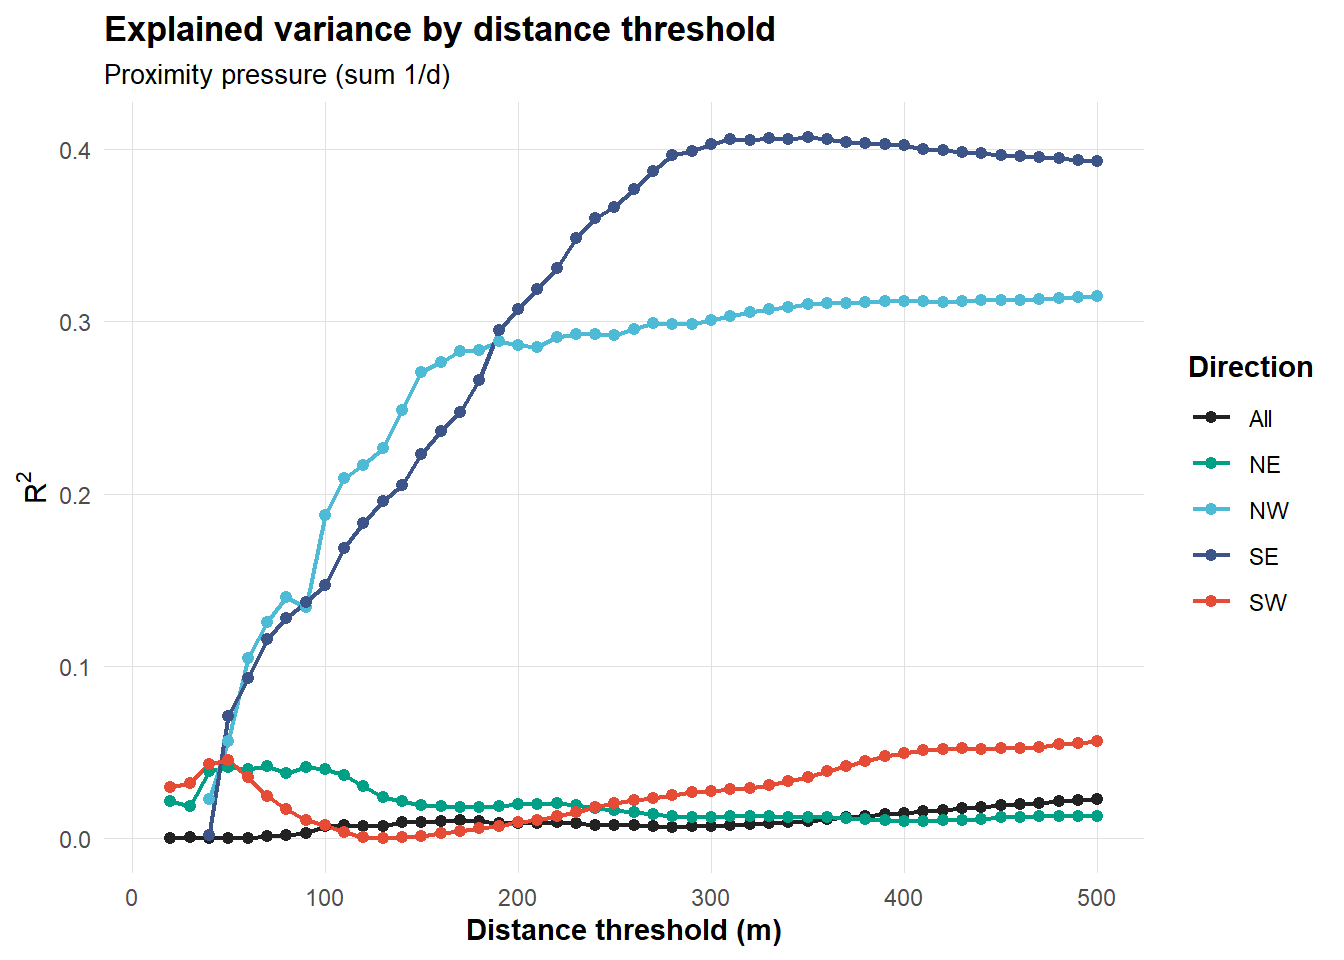

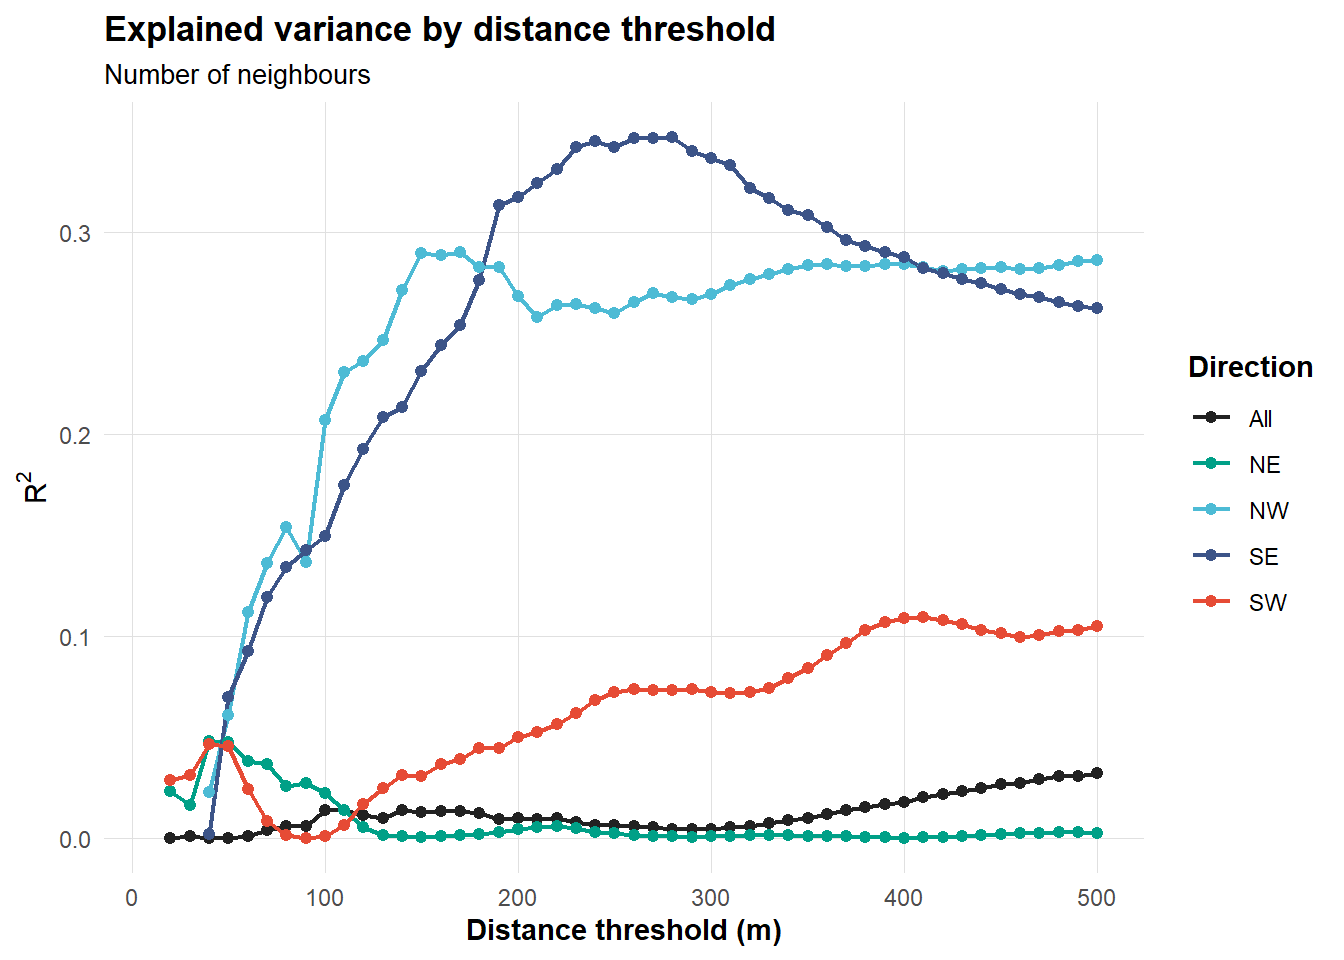

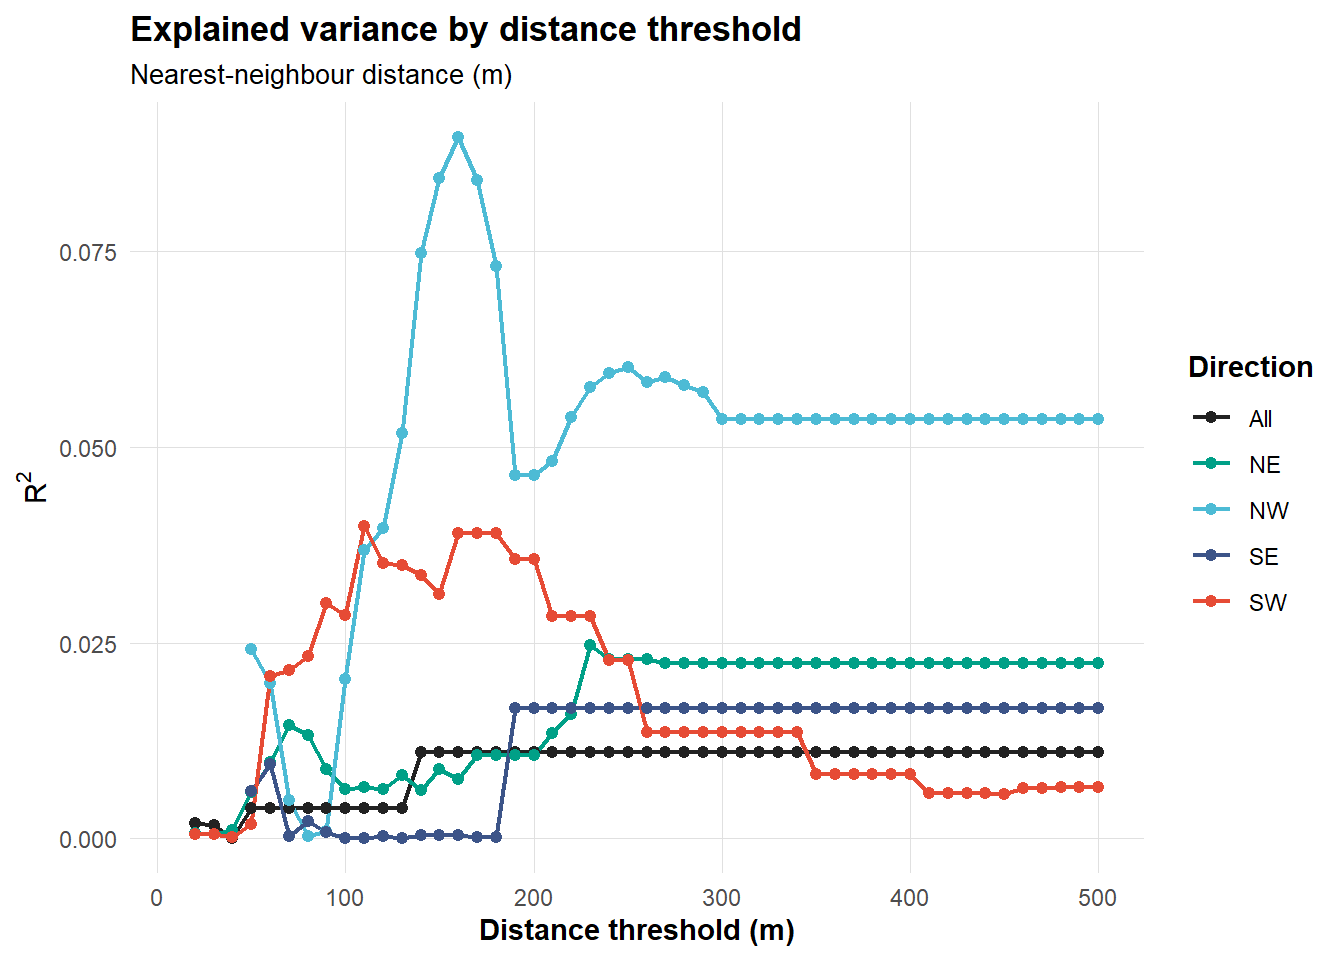

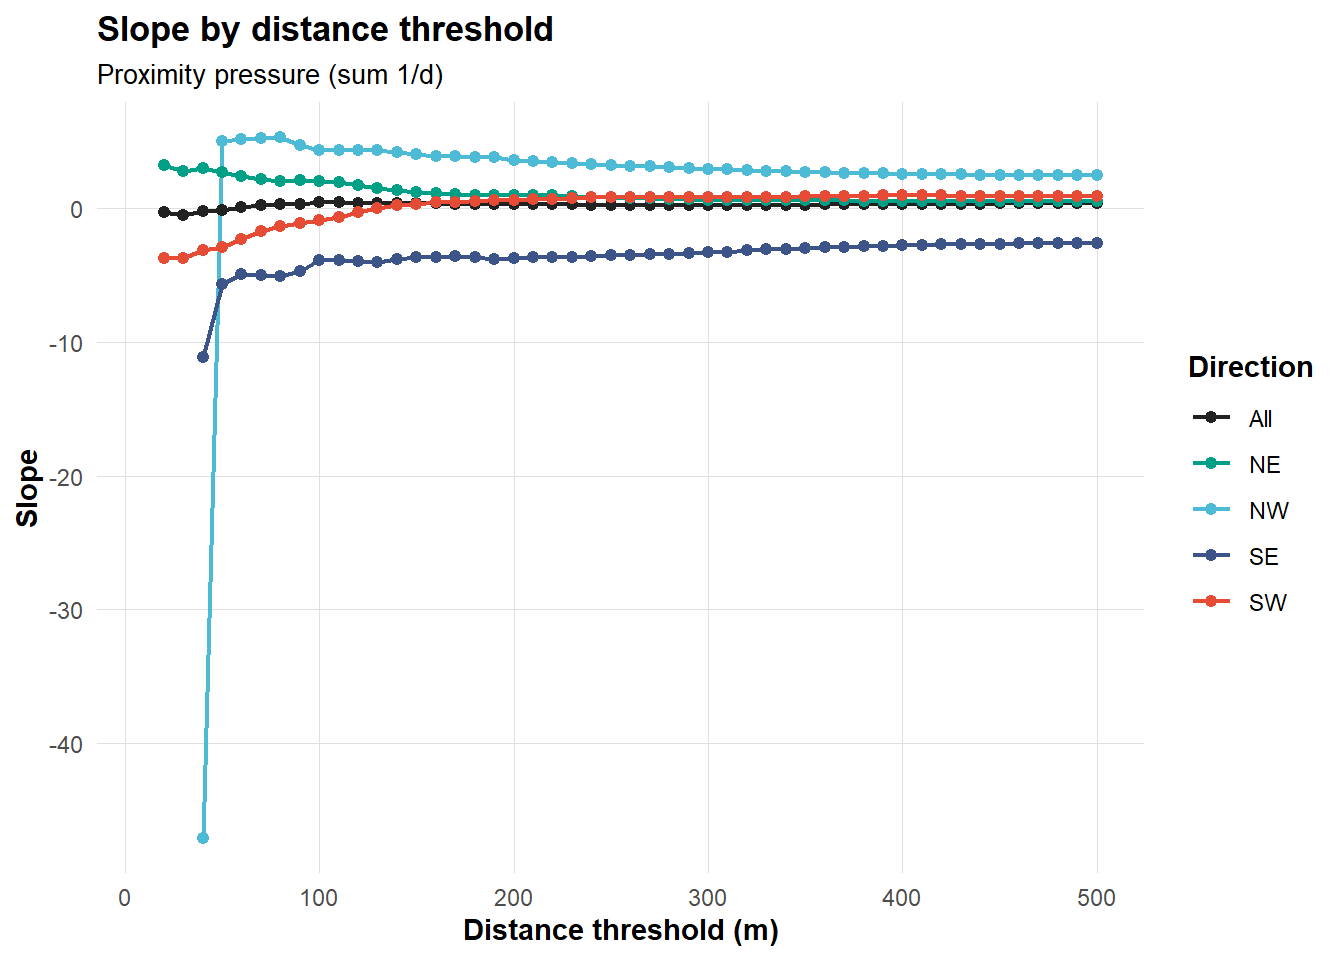

In [ ]:
pressure_r2_plot <- proximity_model_results |>
  filter(predictor == "proximity_pressure") |>
  ggplot(aes(x = distance_threshold_m, y = r_squared, colour = direction)) +
  geom_line(linewidth = 0.8, na.rm = TRUE) +
  geom_point(size = 1.7, na.rm = TRUE) +
  scale_colour_manual(values = direction_palette, drop = FALSE) +
  labs(
    title = "Explained variance by distance threshold",
    subtitle = predictor_labels[["proximity_pressure"]],
    x = "Distance threshold (m)",
    y = expression(R^2),
    colour = "Direction"
  ) +
  theme_spatial()

count_r2_plot <- proximity_model_results |>
  filter(predictor == "n_neighbours") |>
  ggplot(aes(x = distance_threshold_m, y = r_squared, colour = direction)) +
  geom_line(linewidth = 0.8, na.rm = TRUE) +
  geom_point(size = 1.7, na.rm = TRUE) +
  scale_colour_manual(values = direction_palette, drop = FALSE) +
  labs(
    title = "Explained variance by distance threshold",
    subtitle = predictor_labels[["n_neighbours"]],
    x = "Distance threshold (m)",
    y = expression(R^2),
    colour = "Direction"
  ) +
  theme_spatial()

nearest_r2_plot <- proximity_model_results |>
  filter(predictor == "nearest_distance_m") |>
  ggplot(aes(x = distance_threshold_m, y = r_squared, colour = direction)) +
  geom_line(linewidth = 0.8, na.rm = TRUE) +
  geom_point(size = 1.7, na.rm = TRUE) +
  scale_colour_manual(values = direction_palette, drop = FALSE) +
  labs(
    title = "Explained variance by distance threshold",
    subtitle = predictor_labels[["nearest_distance_m"]],
    x = "Distance threshold (m)",
    y = expression(R^2),
    colour = "Direction"
  ) +
  theme_spatial()

pressure_slope_plot <- proximity_model_results |>
  filter(predictor == "proximity_pressure") |>
  ggplot(aes(x = distance_threshold_m, y = slope, colour = direction)) +
  geom_line(linewidth = 0.8, na.rm = TRUE) +
  geom_point(size = 1.7, na.rm = TRUE) +
  scale_colour_manual(values = direction_palette, drop = FALSE) +
  labs(
    title = "Slope by distance threshold",
    subtitle = predictor_labels[["proximity_pressure"]],
    x = "Distance threshold (m)",
    y = "Slope",
    colour = "Direction"
  ) +
  theme_spatial()

save_plot(
  pressure_r2_plot,
  file.path(output_dir, "proximity_pressure_r2_by_distance_direction.png")
)
save_plot(
  count_r2_plot,
  file.path(output_dir, "neighbour_count_r2_by_distance_direction.png")
)
save_plot(
  nearest_r2_plot,
  file.path(output_dir, "nearest_distance_r2_by_distance_direction.png")
)
save_plot(
  pressure_slope_plot,
  file.path(output_dir, "proximity_pressure_slope_by_distance_direction.png")
)

pressure_r2_plot


## Best Directional Relationships

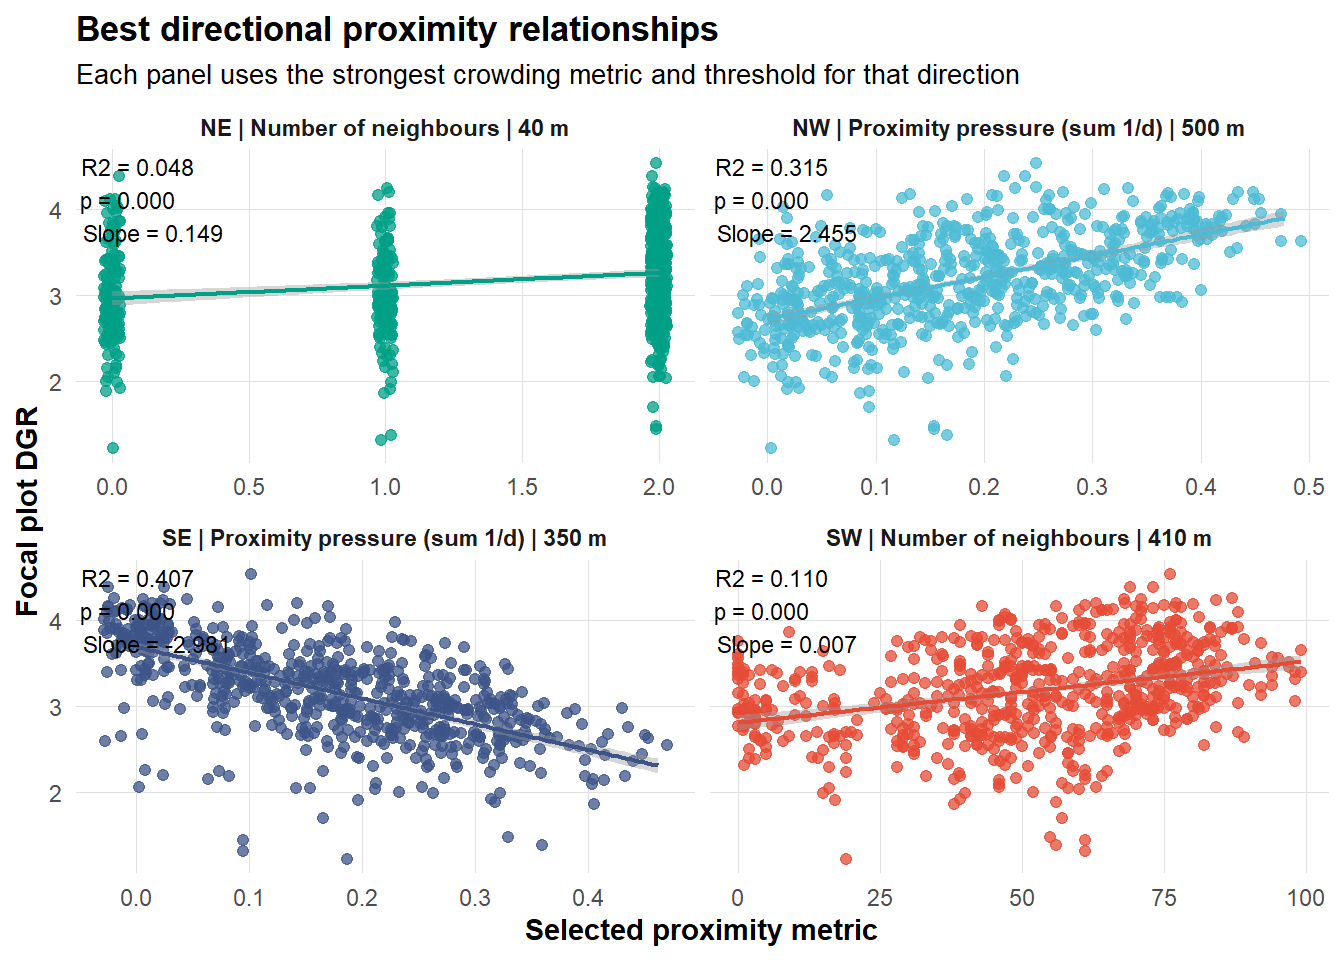

In [ ]:
best_relationship_data <- strongest_by_direction |>
  filter(direction != "All", !is.na(best_predictor)) |>
  select(direction, best_predictor, selected_threshold_m = best_r2_threshold_m) |>
  inner_join(
    proximity_metrics_tbl,
    by = "direction"
  ) |>
  filter(distance_threshold_m == selected_threshold_m) |>
  mutate(
    predictor_value = case_when(
      best_predictor == "has_neighbour" ~ as.numeric(has_neighbour),
      best_predictor == "n_neighbours" ~ as.numeric(n_neighbours),
      best_predictor == "neighbour_density_per_ha" ~ as.numeric(neighbour_density_per_ha),
      best_predictor == "proximity_pressure" ~ as.numeric(proximity_pressure),
      best_predictor == "nearest_distance_m" ~ as.numeric(nearest_distance_m),
      TRUE ~ NA_real_
    ),
    predictor_label = predictor_labels[best_predictor],
    panel_label = paste0(
      direction,
      " | ",
      predictor_labels[best_predictor],
      " | ",
      selected_threshold_m,
      " m"
    ),
    panel_label = factor(panel_label, levels = unique(panel_label))
  )

best_relationship_annotations <- strongest_by_direction |>
  filter(direction != "All") |>
  mutate(
    panel_label = paste0(
      direction,
      " | ",
      predictor_labels[best_predictor],
      " | ",
      best_r2_threshold_m,
      " m"
    ),
    annotation = sprintf(
      "R2 = %.3f\np = %.3f\nSlope = %.3f",
      best_r2,
      best_p_value,
      best_slope
    )
  )

best_relationship_plot <- best_relationship_data |>
  ggplot(aes(x = predictor_value, y = DGR, colour = direction)) +
  geom_point(
    alpha = 0.75,
    size = 1.7,
    position = position_jitter(width = 0.03, height = 0),
    na.rm = TRUE
  ) +
  geom_smooth(
    method = "lm",
    formula = y ~ x,
    se = TRUE,
    linewidth = 0.8,
    na.rm = TRUE
  ) +
  facet_wrap(~ panel_label, scales = "free_x") +
  geom_text(
    data = best_relationship_annotations,
    aes(x = -Inf, y = Inf, label = annotation),
    inherit.aes = FALSE,
    hjust = -0.05,
    vjust = 1.1,
    size = 3.0,
    colour = "black"
  ) +
  scale_colour_manual(values = direction_palette, drop = FALSE) +
  labs(
    title = "Best directional proximity relationships",
    subtitle = "Each panel uses the strongest crowding metric and threshold for that direction",
    x = "Selected proximity metric",
    y = "Focal plot DGR",
    colour = "Direction"
  ) +
  theme_spatial() +
  theme(legend.position = "none")

save_plot(
  best_relationship_plot,
  file.path(output_dir, "best_proximity_directional_relationships.png"),
  width = 11,
  height = 7.5
)

best_relationship_plot


## Summary Figure

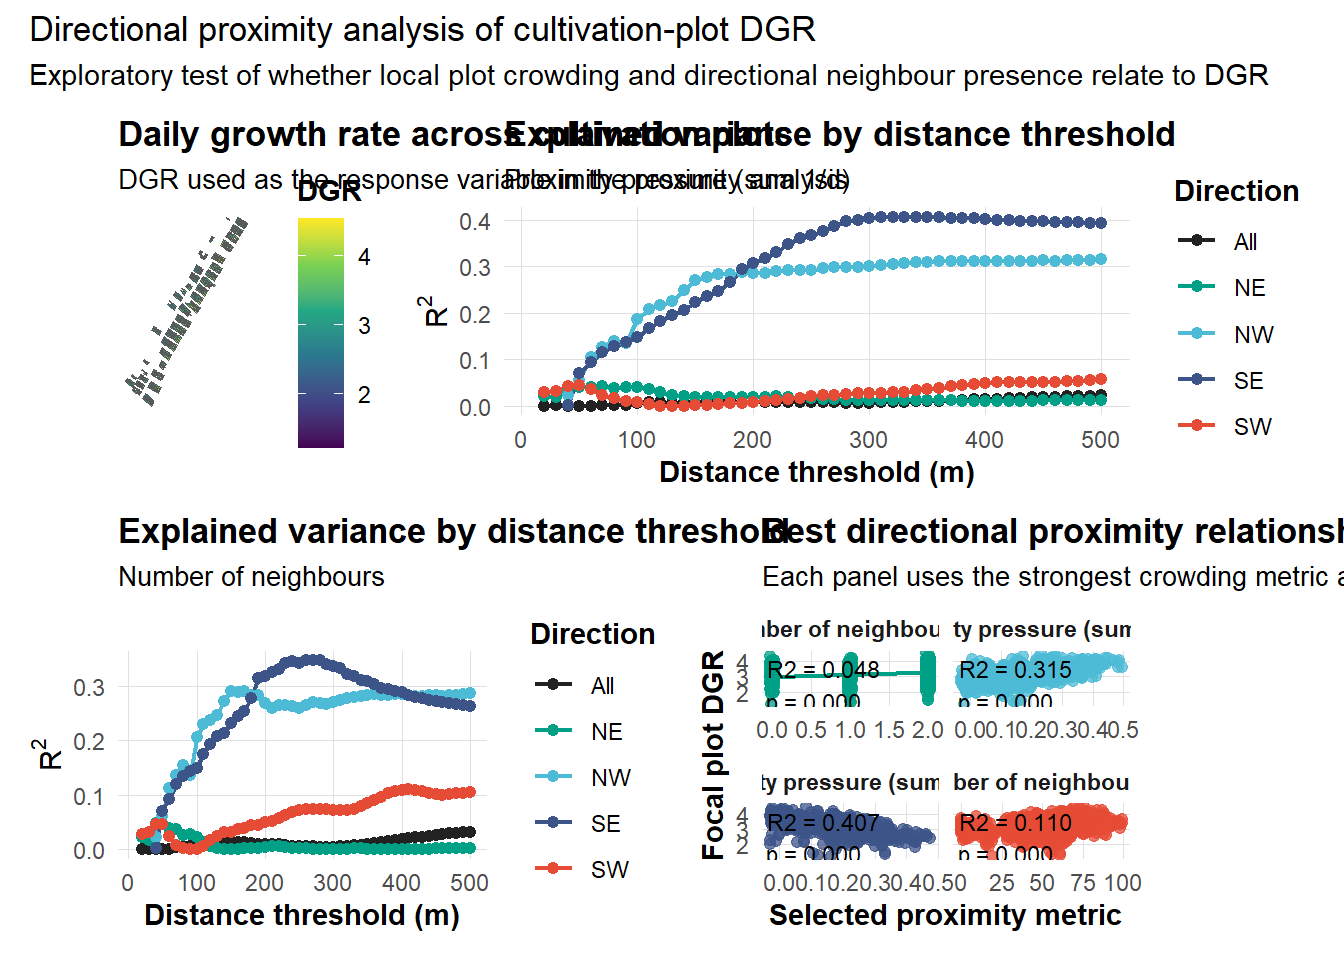

In [ ]:
summary_figure <- (dgr_map | pressure_r2_plot) / (count_r2_plot | best_relationship_plot) +
  plot_annotation(
    title = "Directional proximity analysis of cultivation-plot DGR",
    subtitle = "Exploratory test of whether local plot crowding and directional neighbour presence relate to DGR"
  )

save_plot(
  summary_figure,
  file.path(output_dir, "plot_proximity_analysis_summary_figure.png"),
  width = 14,
  height = 10
)

summary_figure


## Automated Interpretation File

In [ ]:
strongest_overall_row <- strongest_by_direction |>
  filter(direction == "All")

write_interpretation(
  output_file = file.path(output_dir, "plot_proximity_analysis_interpretation.md"),
  metadata = metadata,
  strongest_overall_row = strongest_overall_row,
  strongest_directional_rows = strongest_by_direction,
  best_summary = best_summary
)


## Console Summary

In [ ]:
cat("\nPlot proximity analysis complete.\n")



Plot proximity analysis complete.

Outputs saved to: C:/Users/Simon/Nextcloud/Papers/First Authors/MadaKapPy_Paper_2026/Figures/Spatial_analysis 

Strongest directional proximity relationship: SE at 350 m using Proximity pressure (sum 1/d) (R2 = 0.407, slope = -2.981, p = 0.000).